In [2]:
#Stage 4: Feature Optimization Layer — Part 2
# Purpose : Use LASSO to reduce 52+ features to top-K
#           most important ones for XGBoost training
# Input   : feature_groups.csv (from notebook 04)
# Output  : selected_features.csv + selected_feature_names.pkl

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
 
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})
 
PROC_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..', 'Data', 'processed'))
MODEL_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'models'))
PLOT_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs', 'plots'))
 
os.makedirs(PLOT_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
 
df = pd.read_csv(os.path.join(PROC_DIR, 'feature_groups.csv'))
print(f"Loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"NaN count: {df.isnull().sum().sum()}")

Loaded: (58596, 59)
Columns: ['pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_ethread_pool_false_avg', 'psxview.not_in_pspc

In [4]:
# ── CELL 3 ──────────────────────────────────────────────────────
# Separate features and labels
label_cols = [c for c in ['Class', 'Category'] if c in df.columns]
y_raw      = df['Class'].copy()
X          = df.drop(columns=label_cols).select_dtypes(include=[np.number]).copy()
 
# Encode label: Benign=0, Malicious=1
le = LabelEncoder()
y  = pd.Series(le.fit_transform(y_raw), name='Class')
 
print(f"Feature matrix : {X.shape}")
print(f"Label encoding : {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Class balance  : {y.value_counts().to_dict()}")
print(f"NaN in X       : {X.isnull().sum().sum()}")
print(f"\nFeature columns ({X.shape[1]}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:02d}. {col}")

Feature matrix : (58596, 57)
Label encoding : {'Benign': 0, 'Malware': 1}
Class balance  : {0: 29298, 1: 29298}
NaN in X       : 0

Feature columns (57):
  01. pslist.nproc
  02. pslist.nppid
  03. pslist.avg_threads
  04. pslist.avg_handlers
  05. dlllist.ndlls
  06. dlllist.avg_dlls_per_proc
  07. handles.nhandles
  08. handles.avg_handles_per_proc
  09. handles.nfile
  10. handles.nevent
  11. handles.ndesktop
  12. handles.nkey
  13. handles.nthread
  14. handles.ndirectory
  15. handles.nsemaphore
  16. handles.ntimer
  17. handles.nsection
  18. handles.nmutant
  19. ldrmodules.not_in_load
  20. ldrmodules.not_in_init
  21. ldrmodules.not_in_mem
  22. ldrmodules.not_in_load_avg
  23. ldrmodules.not_in_init_avg
  24. ldrmodules.not_in_mem_avg
  25. malfind.ninjections
  26. malfind.commitCharge
  27. malfind.protection
  28. malfind.uniqueInjections
  29. psxview.not_in_pslist
  30. psxview.not_in_eprocess_pool
  31. psxview.not_in_ethread_pool
  32. psxview.not_in_pspcid_list
  3

In [6]:
 #Train/Test split for LASSO fitting
X_train_ls, X_test_ls, y_train_ls, y_test_ls = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
 
print(f"LASSO train : {X_train_ls.shape[0]:,}")
print(f"LASSO test  : {X_test_ls.shape[0]:,}")

LASSO train : 46,876
LASSO test  : 11,720


In [7]:
# ── CELL 5 ──────────────────────────────────────────────────────
# Apply LassoCV — finds best regularization alpha via cross-validation
print("Running LassoCV (5-fold CV) — please wait 1-2 minutes...")
 
lasso = LassoCV(
    cv          = 5,
    random_state= 42,
    max_iter    = 10000,
    n_jobs      = -1,
    eps         = 1e-4
)
lasso.fit(X_train_ls, y_train_ls)
 
print(f"\nLassoCV complete!")
print(f"  Best alpha (regularization) : {lasso.alpha_:.8f}")
print(f"  Non-zero coefficients       : {np.sum(lasso.coef_ != 0)}")
print(f"  Zero coefficients (removed) : {np.sum(lasso.coef_ == 0)}")
 
# Show all coefficients
coef_df = pd.DataFrame({
    'feature'    : X.columns,
    'coefficient': lasso.coef_,
    'abs_coef'   : np.abs(lasso.coef_)
}).sort_values('abs_coef', ascending=False)
 
print(f"\nAll feature coefficients:")
print(coef_df.to_string(index=False))

Running LassoCV (5-fold CV) — please wait 1-2 minutes...

LassoCV complete!
  Best alpha (regularization) : 0.00001875
  Non-zero coefficients       : 33
  Zero coefficients (removed) : 24

All feature coefficients:
                               feature  coefficient  abs_coef
                      handles.nsection   -11.757171 11.757171
       svcscan.shared_process_services    -7.726200  7.726200
                    svcscan.fs_drivers     5.960972  5.960972
                      modules.nmodules     5.847301  5.847301
                      handles.ndesktop    -5.150376  5.150376
                    handles.ndirectory     4.525550  4.525550
                svcscan.kernel_drivers     3.008896  3.008896
             dlllist.avg_dlls_per_proc    -2.843064  2.843064
 psxview.not_in_ethread_pool_false_avg    -2.606355  2.606355
                         dlllist.ndlls     1.720822  1.720822
                   pslist.avg_handlers    -1.661135  1.661135
            ldrmodules.not_in_init_avg  

In [8]:
# ── CELL 6 ──────────────────────────────────────────────────────
# Select features with non-zero LASSO coefficients
selector = SelectFromModel(lasso, prefit=True)
X_selected       = selector.transform(X)
selected_mask    = selector.get_support()
selected_names   = X.columns[selected_mask].tolist()
 
print(f"Features before LASSO : {X.shape[1]}")
print(f"Features after LASSO  : {len(selected_names)}")
print(f"Reduction             : {X.shape[1] - len(selected_names)} features removed")
print(f"\nSelected feature names:")
for i, name in enumerate(selected_names, 1):
    print(f"  {i:02d}. {name}")
 
# Fallback: if LASSO removes too many, keep top 20 by abs coefficient
if len(selected_names) < 5:
    print("\nWARNING: LASSO removed too many features. Using top 20 by abs coefficient.")
    top_features   = coef_df[coef_df['abs_coef'] > 0].head(20)['feature'].tolist()
    if len(top_features) < 5:
        top_features = coef_df.head(20)['feature'].tolist()
    selected_names = top_features
    X_selected     = X[selected_names].values
    print(f"Using {len(selected_names)} features by fallback")

Features before LASSO : 57
Features after LASSO  : 33
Reduction             : 24 features removed

Selected feature names:
  01. pslist.nproc
  02. pslist.avg_threads
  03. pslist.avg_handlers
  04. dlllist.ndlls
  05. dlllist.avg_dlls_per_proc
  06. handles.avg_handles_per_proc
  07. handles.nevent
  08. handles.ndesktop
  09. handles.nkey
  10. handles.nthread
  11. handles.ndirectory
  12. handles.nsemaphore
  13. handles.ntimer
  14. handles.nsection
  15. handles.nmutant
  16. ldrmodules.not_in_load
  17. ldrmodules.not_in_init
  18. ldrmodules.not_in_mem
  19. ldrmodules.not_in_load_avg
  20. ldrmodules.not_in_init_avg
  21. malfind.ninjections
  22. malfind.commitCharge
  23. psxview.not_in_eprocess_pool_false_avg
  24. psxview.not_in_ethread_pool_false_avg
  25. psxview.not_in_session_false_avg
  26. psxview.not_in_deskthrd_false_avg
  27. modules.nmodules
  28. svcscan.kernel_drivers
  29. svcscan.fs_drivers
  30. svcscan.shared_process_services
  31. svcscan.nactive
  32. cal

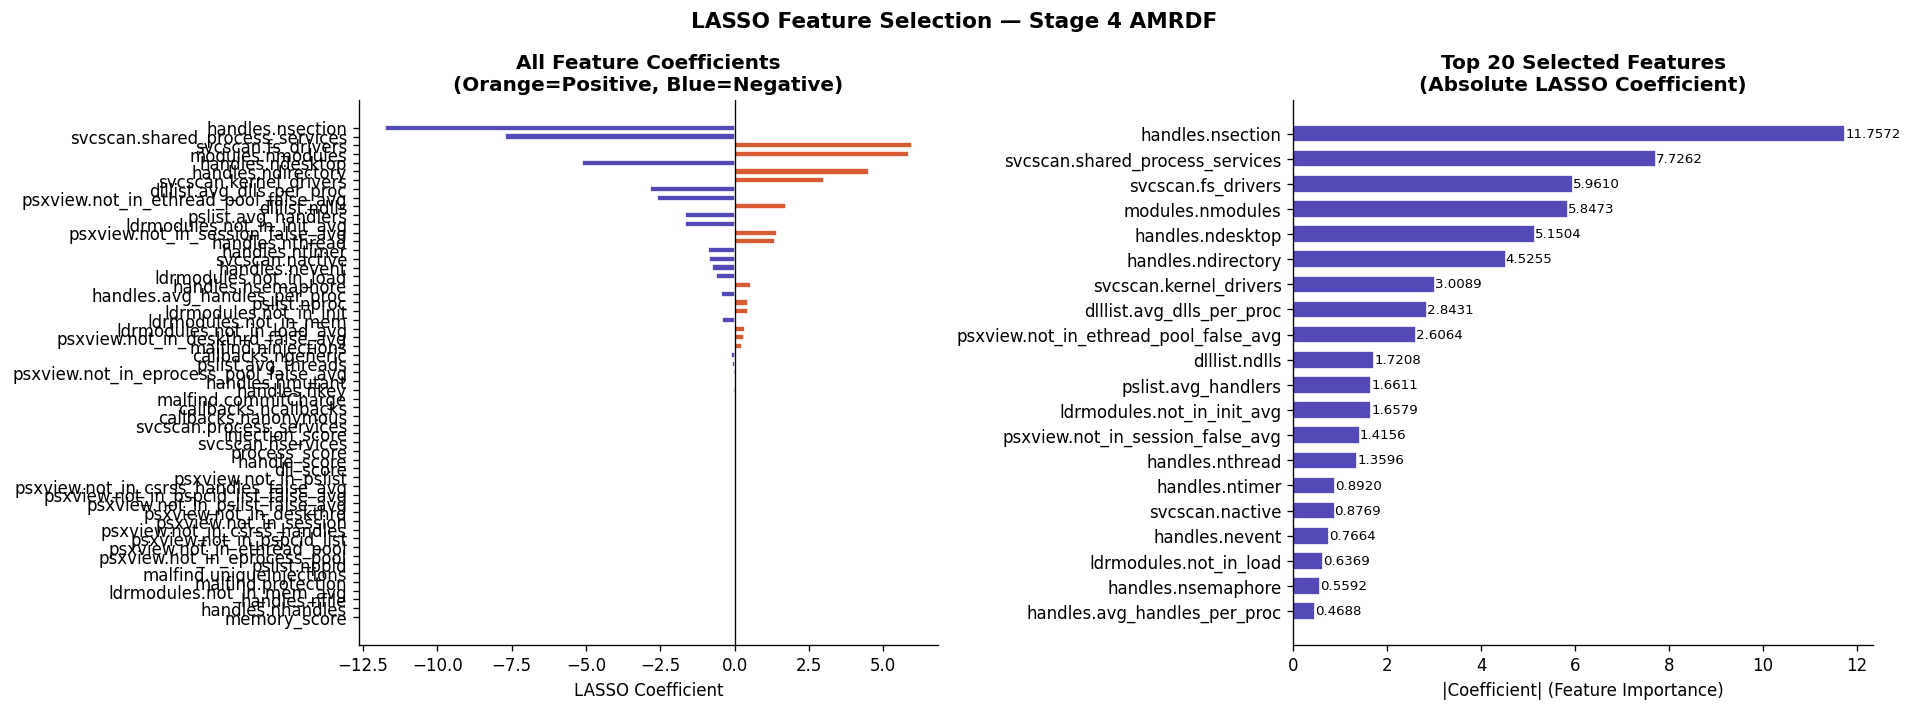

Saved: lasso_feature_selection.png


In [9]:
# ── CELL 7 ──────────────────────────────────────────────────────
# Plot LASSO coefficients
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Panel 1 — All coefficients
coef_plot = coef_df.copy()
colors    = ['#D85A30' if v > 0 else '#534AB7'
             for v in coef_plot['coefficient']]
axes[0].barh(coef_plot['feature'], coef_plot['coefficient'],
             color=colors, edgecolor='white', height=0.7)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('LASSO Coefficient')
axes[0].set_title('All Feature Coefficients\n(Orange=Positive, Blue=Negative)',
                  fontweight='bold')
axes[0].invert_yaxis()
 
# Panel 2 — Top selected features by absolute coefficient
top20 = coef_df[coef_df['abs_coef'] > 0].head(20)
axes[1].barh(top20['feature'], top20['abs_coef'],
             color='#534AB7', edgecolor='white', height=0.7)
axes[1].set_xlabel('|Coefficient| (Feature Importance)')
axes[1].set_title(f'Top {len(top20)} Selected Features\n(Absolute LASSO Coefficient)',
                  fontweight='bold')
axes[1].invert_yaxis()
 
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 0.0001,
                 bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.4f}',
                 va='center', fontsize=8)
 
plt.suptitle('LASSO Feature Selection — Stage 4 AMRDF',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'lasso_feature_selection.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lasso_feature_selection.png")

In [10]:
# ── CELL 8 ──────────────────────────────────────────────────────
# Save selected features dataset and names
X_sel_df          = pd.DataFrame(X_selected, columns=selected_names)
X_sel_df['Class'] = y.values
 
out_path = os.path.join(PROC_DIR, 'selected_features.csv')
X_sel_df.to_csv(out_path, index=False)
joblib.dump(selected_names,
            os.path.join(MODEL_DIR, 'selected_feature_names.pkl'))
joblib.dump(le,
            os.path.join(MODEL_DIR, 'label_encoder.pkl'))
 
print(f"Saved: selected_features.csv — shape: {X_sel_df.shape}")
print(f"Saved: selected_feature_names.pkl")
print(f"Saved: label_encoder.pkl")
print(f"\nFeature count: {X.shape[1]} → {len(selected_names)}")
print("\nNotebook 05 complete — proceed to 06_xgboost_training.ipynb")
 

Saved: selected_features.csv — shape: (58596, 34)
Saved: selected_feature_names.pkl
Saved: label_encoder.pkl

Feature count: 57 → 33

Notebook 05 complete — proceed to 06_xgboost_training.ipynb
